# Generate ALL future-path overlay images for one sequence

This notebook projects the robot's future driving path into **every image** of one RELLIS-3D
sequence and saves the overlay pictures (**green ribbon** = the strip of ground the robot will
drive over, **red line** = the exact path of the robot's center).

It is the same, already-verified projection as `project_future_poses.ipynb` — the
difference is that notebook 03 saved a debug overlay only every 25th frame, while this one
saves **every frame that has a future path** (frames with no path, e.g. the last frames of
the sequence are skipped).

Output folder: `full_outputs/<sequence>/`.

## 0. Settings — pick the sequence here

In [2]:
from pathlib import Path

# ======== INPUT: which sequence to process ========
SEQUENCE = '00002'          # '00000', '00001', '00002', '00003' or '00004'
# ==================================================

DATA_ROOT = Path('s:/#UNIVERSITY/Capstone/Code/Rellis_Stepp/Rellis_3D')
OUT_DIR   = Path('s:/#UNIVERSITY/Capstone/Code/Rellis_Stepp/full_outputs') / SEQUENCE
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEQ_DIR   = DATA_ROOT / SEQUENCE
IMG_DIR   = SEQ_DIR / 'pylon_camera_node'

# image size and projection settings (same values as notebook 03)
IMG_W, IMG_H    = 1920, 1200
FUTURE_STEPS    = 50     # how many future poses to project
MIN_MOVE_M      = 0.10   # skip frames where the robot moved less than 10 cm
GROUND_OFFSET_M = 1.00   # sensor height above the ground
ROBOT_WIDTH_M   = 1.0    # width of the green ribbon
MIN_Z           = 0.5    # ignore path points closer than 0.5 m / behind the camera

assert IMG_DIR.is_dir(), f'sequence folder not found: {IMG_DIR}'
print('sequence:', SEQUENCE, '\noutput  :', OUT_DIR)

sequence: 00002 
output  : s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\full_outputs\00002


## 1. Load images, poses, camera settings

In [3]:
import numpy as np
import cv2
import yaml
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation

# ---- images and poses (one pose line per image, same order) ----
image_paths = sorted(IMG_DIR.glob('*.jpg'))
pose_lines = [l for l in (SEQ_DIR / 'poses.txt').read_text().splitlines() if l.strip()]
print(f'{len(image_paths)} images, {len(pose_lines)} pose lines')
assert len(image_paths) == len(pose_lines), 'images and poses do not match!'

def pose_line_to_matrix(line):
    """One poses.txt line (12 numbers) -> 4x4 pose matrix of the LiDAR in the world."""
    values = np.array(line.split(), dtype=np.float64)
    T = np.eye(4)
    T[:3, :4] = values.reshape(3, 4)
    return T

T_world_lidar = np.stack([pose_line_to_matrix(l) for l in pose_lines])

# ---- camera intrinsics (fx fy cx cy) ----
fx, fy, cx, cy = np.loadtxt(SEQ_DIR / 'camera_info.txt').ravel()[:4]
K = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]], dtype=np.float64)
D = np.zeros(5)   # this dataset export has no distortion coefficients

# ---- camera<->LiDAR mounting transform from transforms.yaml ----
# (direction verified in notebook 03: use the yaml transform AS-IS)
tf = yaml.safe_load((SEQ_DIR / 'transforms.yaml').read_text())
key = next(k for k in tf if 'os1' in k and 'pylon' in k)
q, t = tf[key]['q'], tf[key]['t']
T_yaml = np.eye(4)
T_yaml[:3, :3] = Rotation.from_quat([q['x'], q['y'], q['z'], q['w']]).as_matrix()
T_yaml[:3, 3] = [t['x'], t['y'], t['z']]

T_world_cam = T_world_lidar @ T_yaml    # camera pose in the world, for every frame
print('poses ready')

4147 images, 4147 pose lines
poses ready


## 2. Drop near-stationary frames (images and poses stay in step)

In [5]:
keep = [0]
for i in range(1, len(T_world_cam)):
    moved = np.linalg.norm(T_world_cam[i, :3, 3] - T_world_cam[keep[-1], :3, 3])
    if moved >= MIN_MOVE_M:
        keep.append(i)

images = [image_paths[i] for i in keep]
T_cam  = T_world_cam[keep]
T_lid  = T_world_lidar[keep]
print(f'kept {len(keep)} of {len(image_paths)} frames after the {MIN_MOVE_M} m filter')

kept 3573 of 4147 frames after the 0.1 m filter


## 3. The projection functions (same math as future pose projection)

In [6]:
def future_ground_strip(idx):
    """Ground points of the future path: center line and left/right edges (world coords)."""
    center, left_edge, right_edge = [], [], []
    for j in range(idx + 1, min(idx + 1 + FUTURE_STEPS, len(T_lid))):
        position = T_lid[j][:3, 3]
        forward = T_lid[j][:3, 0].copy()       # robot forward direction
        forward[2] = 0.0
        length = np.linalg.norm(forward)
        if length < 1e-6:
            continue
        forward = forward / length
        left = np.array([-forward[1], forward[0], 0.0])
        ground = position - np.array([0.0, 0.0, GROUND_OFFSET_M])
        center.append(ground)
        left_edge.append(ground + 0.5 * ROBOT_WIDTH_M * left)
        right_edge.append(ground - 0.5 * ROBOT_WIDTH_M * left)
    return np.array(center), np.array(left_edge), np.array(right_edge)

def world_to_pixels(points_world, idx):
    """Project world points into the image of frame idx. NaN where not visible."""
    if len(points_world) == 0:
        return np.zeros((0, 2)), np.zeros(0, bool)
    world_to_cam = np.linalg.inv(T_cam[idx])
    pts_cam = points_world @ world_to_cam[:3, :3].T + world_to_cam[:3, 3]
    visible = pts_cam[:, 2] > MIN_Z
    pixels = np.full((len(points_world), 2), np.nan)
    if visible.any():
        projected, _ = cv2.projectPoints(pts_cam[visible].reshape(-1, 1, 3),
                                         np.zeros(3), np.zeros(3), K, D)
        pixels[visible] = projected.reshape(-1, 2)
    return pixels, visible

def path_mask_and_centerline(idx):
    """Binary mask of the green ribbon + the projected centerline points."""
    mask = np.zeros((IMG_H, IMG_W), np.uint8)
    center, left_edge, right_edge = future_ground_strip(idx)
    if len(center) < 2:
        return mask, np.zeros((0, 2))
    pix_left,  vis_left  = world_to_pixels(left_edge, idx)
    pix_right, vis_right = world_to_pixels(right_edge, idx)
    pix_center, vis_center = world_to_pixels(center, idx)
    for j in range(len(center) - 1):
        if not (vis_left[j] and vis_right[j] and vis_left[j + 1] and vis_right[j + 1]):
            continue
        quad = np.array([pix_left[j], pix_left[j + 1], pix_right[j + 1], pix_right[j]])
        quad = np.clip(quad, -30000, 30000).astype(np.int32)
        if quad[:, 0].max() < 0 or quad[:, 0].min() >= IMG_W:
            continue
        if quad[:, 1].max() < 0 or quad[:, 1].min() >= IMG_H:
            continue
        cv2.fillPoly(mask, [quad], 1)
    return mask, pix_center[vis_center]

def make_overlay(image_bgr, mask, centerline):
    """Draw the green ribbon and the red centerline on a copy of the image."""
    overlay = image_bgr.copy()
    ribbon = mask > 0
    overlay[ribbon] = (0.45 * overlay[ribbon] + 0.55 * np.array([0, 255, 0])).astype(np.uint8)
    inside = centerline[np.all((centerline >= 0) & (centerline < [IMG_W, IMG_H]), axis=1)]
    if len(inside) >= 2:
        cv2.polylines(overlay, [inside.astype(np.int32)], False, (0, 0, 255), 4)
    return overlay

## 4. Generate and save the overlay for EVERY frame with a path

Frames whose future path is empty (end of the sequence, or the path is completely outside
the picture during sharp turns) are skipped — only images **with** a future path are saved.

In [6]:
import time
start = time.time()

n_saved = 0
n_skipped = 0
for i in range(len(images)):
    mask, centerline = path_mask_and_centerline(i)
    if mask.sum() == 0:                     # no future path in this image -> skip
        n_skipped += 1
        continue
    image = cv2.imread(str(images[i]))
    assert image is not None, f'could not read {images[i]}'
    overlay = make_overlay(image, mask, centerline)
    cv2.imwrite(str(OUT_DIR / images[i].name), overlay)
    n_saved += 1
    if i % 200 == 0:
        print(f'{i}/{len(images)} frames done...')

print(f'\nfinished in {(time.time() - start) / 60:.1f} min')
print(f'saved   : {n_saved} overlay images -> {OUT_DIR}')
print(f'skipped : {n_skipped} frames without a future path')

0/3573 frames done...
200/3573 frames done...


KeyboardInterrupt: 

## 5. Show a few of the saved overlays

3441 overlay images in s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\full_outputs\00002


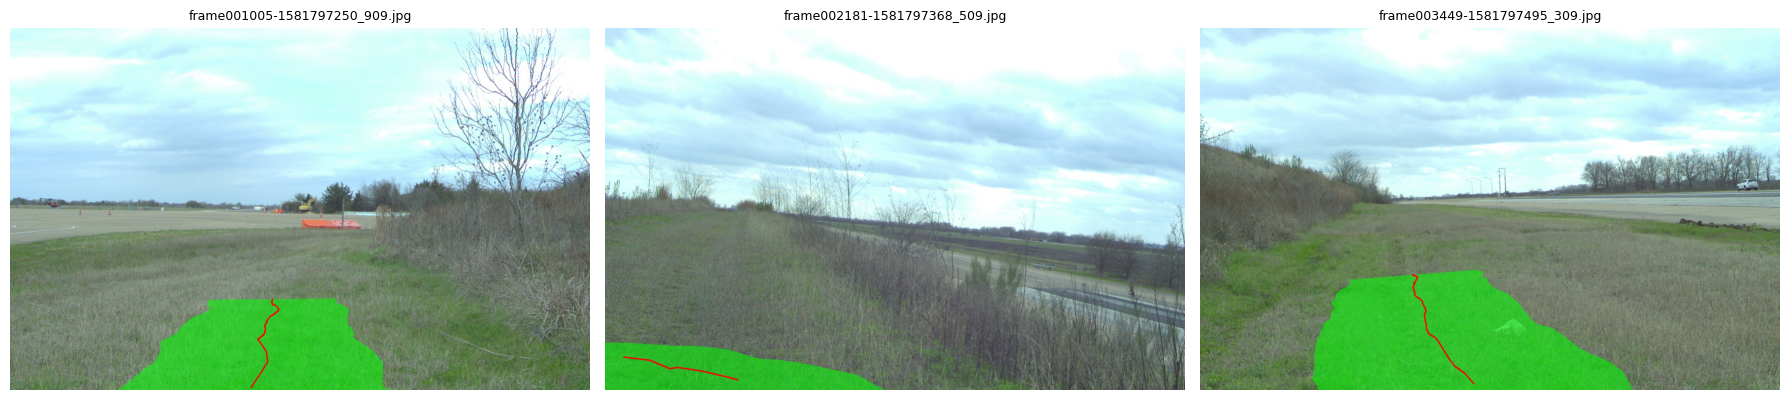

In [7]:
saved_files = sorted(OUT_DIR.glob('*.jpg'))
print(len(saved_files), 'overlay images in', OUT_DIR)

samples = [saved_files[len(saved_files) // 6],
           saved_files[len(saved_files) // 2],
           saved_files[(5 * len(saved_files)) // 6]]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, path in zip(axes, samples):
    picture = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    ax.imshow(picture)
    ax.set_title(path.name, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Also save the SLIC segmented images

For every saved overlay frame, this section also saves a **SLIC segmentation picture**:
- the image is resized to **700×700** (the size the STEPP pipeline uses for SLIC),
- it is split into ~400 superpixels (`n_segments=400, compactness=15`, same as everywhere in
  this project),
- **yellow lines** show the superpixel borders,
- superpixels that the **future path drives over** are tinted **green** — these are exactly
  the segments whose features become the "traversable" training examples in notebook 05.

Saved to `full_outputs/<sequence>/slic/`, same filenames as the overlays.

⏱️ SLIC takes ~0.5 s per image, so all ~3400 frames take roughly **30–40 minutes**.
Set `SLIC_EVERY = 5` (or higher) below for a quicker pass that saves every Nth frame.

In [9]:
from skimage.segmentation import slic, mark_boundaries

SLIC_DIR = OUT_DIR / 'slic'
SLIC_DIR.mkdir(parents=True, exist_ok=True)

SLIC_SIZE   = 700    # STEPP runs SLIC on 700x700 images
N_SEGMENTS  = 400
COMPACTNESS = 15
SLIC_EVERY  = 5      # 1 = every path frame (slow!), 5 = every 5th frame, etc.

start = time.time()
n_saved_slic = 0
for i in range(0, len(images), SLIC_EVERY):
    mask, centerline = path_mask_and_centerline(i)
    if mask.sum() == 0:                    # no future path -> skip (same rule as section 4)
        continue

    image = cv2.imread(str(images[i]))
    assert image is not None, f'could not read {images[i]}'
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    square = cv2.resize(rgb, (SLIC_SIZE, SLIC_SIZE))

    # split the picture into ~400 superpixels
    segments = slic(square, n_segments=N_SEGMENTS, compactness=COMPACTNESS,
                    start_label=0, channel_axis=-1)

    # find which superpixels the future path drives over
    small_mask = cv2.resize(mask, (SLIC_SIZE, SLIC_SIZE), interpolation=cv2.INTER_NEAREST)
    path_segment_ids = np.unique(segments[small_mask > 0])

    # green tint on the path superpixels
    picture = square.copy()
    on_path = np.isin(segments, path_segment_ids)
    picture[on_path] = (0.55 * picture[on_path] + 0.45 * np.array([0, 255, 0])).astype(np.uint8)

    # yellow border lines between all superpixels (mark_boundaries returns values 0..1)
    picture = mark_boundaries(picture, segments, color=(1, 1, 0))
    picture = (picture * 255).astype(np.uint8)

    cv2.imwrite(str(SLIC_DIR / images[i].name), cv2.cvtColor(picture, cv2.COLOR_RGB2BGR))
    n_saved_slic += 1
    if i % 200 == 0:
        print(f'{i}/{len(images)} frames done...')

print(f'\nfinished in {(time.time() - start) / 60:.1f} min')
print(f'saved {n_saved_slic} SLIC images -> {SLIC_DIR}')

0/3573 frames done...
200/3573 frames done...
400/3573 frames done...
600/3573 frames done...
800/3573 frames done...


KeyboardInterrupt: 

In [ ]:
# show a few of the saved SLIC images
slic_files = sorted(SLIC_DIR.glob('*.jpg'))
print(len(slic_files), 'SLIC images in', SLIC_DIR)

samples = [slic_files[len(slic_files) // 6],
           slic_files[len(slic_files) // 2],
           slic_files[(5 * len(slic_files)) // 6]]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, path in zip(axes, samples):
    picture = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    ax.imshow(picture)
    ax.set_title(path.name, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 7. Every image type of the pipeline, side by side

One frame shown in all the forms it takes on its way through the pipeline:

1. **original** — the raw camera image.
2. **path overlay** — green ribbon (future driving corridor) + red centerline.
3. **SLIC on the path** — the ~400 superpixels (yellow borders); the ones the path drives
   over are tinted green.
4. **DINOv2 features** — all 384 feature numbers per patch compressed to 3 PCA values and
   shown as colors (same color = similar features). 50×50 patches.
5. **DINOv3 features** — the same, with DINOv3's 44×44 patches.
6. **training input** — the image with everything *except* the path superpixels blacked out.

⚠️ About panel 6: the autoencoder never actually sees pixels. Its real input is **one
384-number feature vector per green superpixel** (the average of panel 4/5's features inside
that segment). Panel 6 is the closest thing to a picture of that input: only the green
segments' content contributes, everything black is invisible to training.

showing kept frame 1786 -> frame002170-1581797367_409.jpg


C:\Users\jthre/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\jthre/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\jthre/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


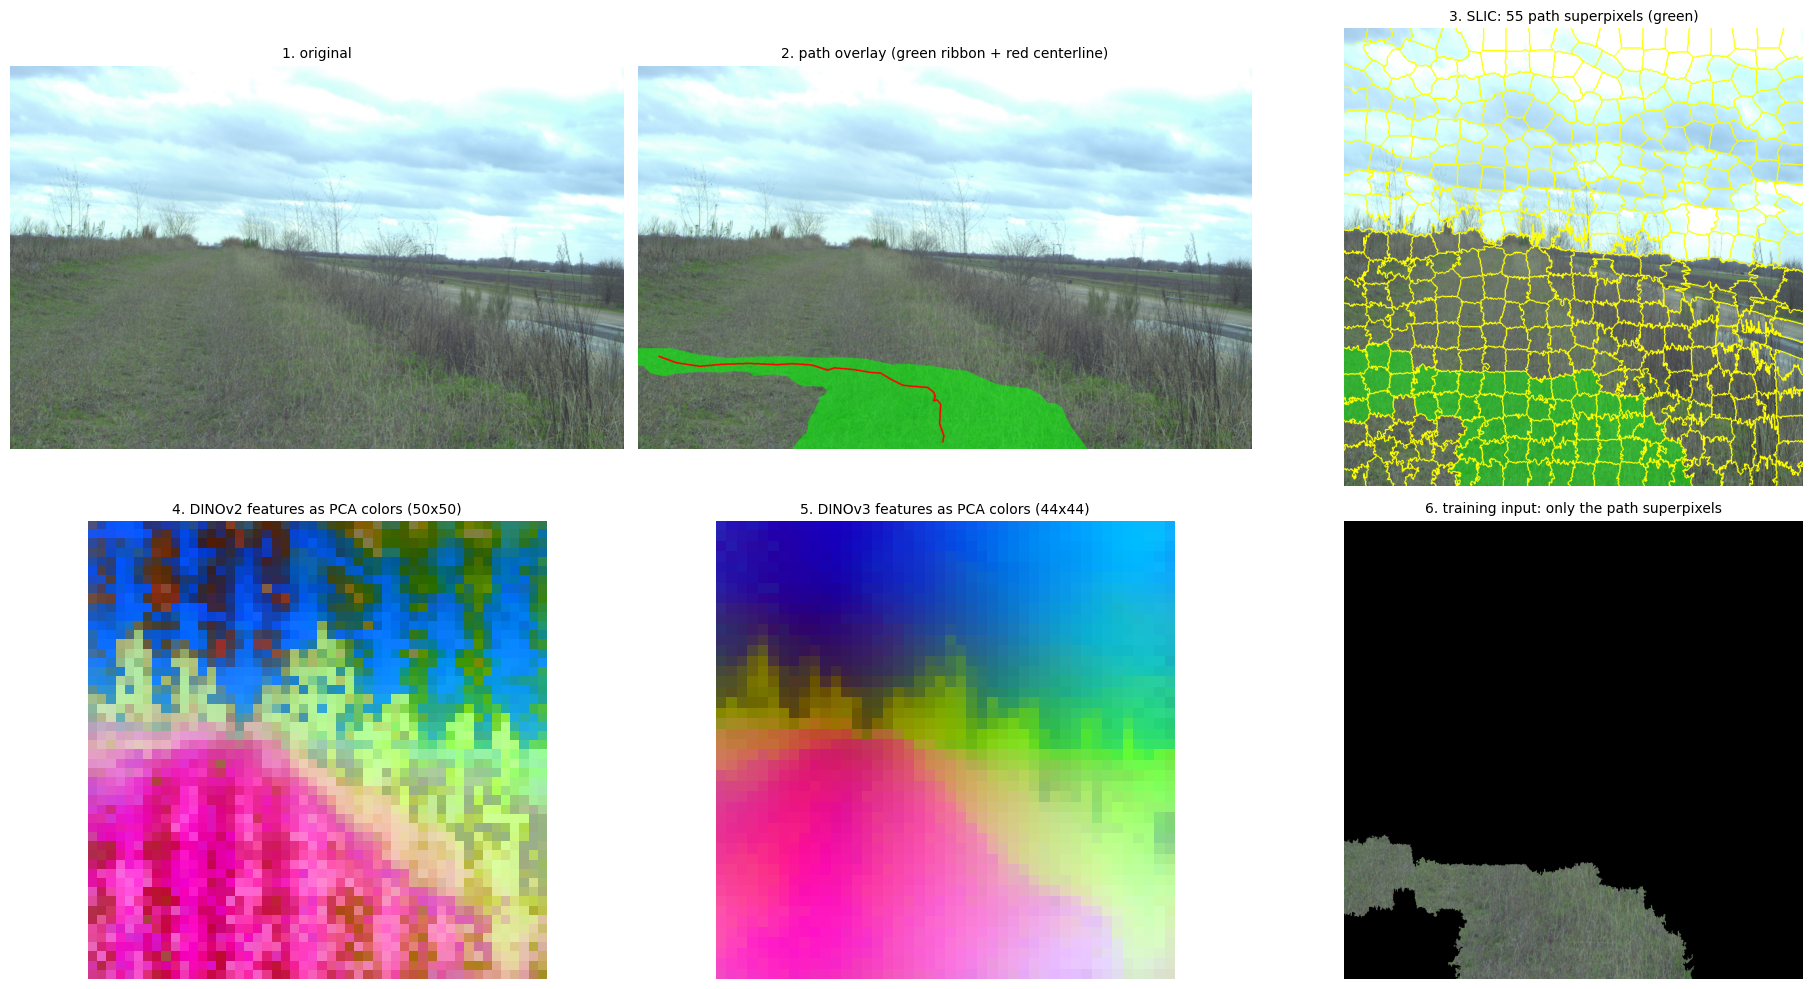

saved -> s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\full_outputs\00002\pipeline_panels_frame002170-1581797367_409.png


In [8]:
import sys
import torch
from torchvision import transforms as tv_transforms
from sklearn.decomposition import PCA

from skimage.segmentation import slic, mark_boundaries


DINOV3_REPO    = Path('C:/Users/jthre/.cache/torch/hub/facebookresearch_dinov3_main')
DINOV3_WEIGHTS = Path('s:/#UNIVERSITY/Capstone/Code/Rellis_Stepp/DinoV3_vits16/dinov3_vits16_pretrain_lvd1689m-08c60483.pth')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
imagenet_norm = tv_transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

def dense_features(model, square_rgb, grid):
    """Run a backbone on a square image -> (grid, grid, 384) numpy feature map."""
    x = torch.from_numpy(square_rgb).permute(2, 0, 1).float() / 255.0
    x = imagenet_norm(x).unsqueeze(0).to(device)
    with torch.no_grad():
        tokens = model.get_intermediate_layers(x, n=1)[0][0]
    return tokens.reshape(grid, grid, 384).cpu().numpy()

def pca_color_image(feature_map):
    """Compress the 384 feature numbers per patch to 3 and show them as colors."""
    flat = feature_map.reshape(-1, 384)
    compressed = PCA(n_components=3).fit_transform(flat)
    low  = np.percentile(compressed, 2, axis=0)
    high = np.percentile(compressed, 98, axis=0)
    colors = np.clip((compressed - low) / (high - low), 0, 1)
    return colors.reshape(feature_map.shape[0], feature_map.shape[1], 3)

# ---- pick a frame that has a future path (starts at the sequence middle) ----
SHOW_FRAME = len(images) // 2
mask, centerline = path_mask_and_centerline(SHOW_FRAME)
while mask.sum() == 0:
    SHOW_FRAME += 1
    mask, centerline = path_mask_and_centerline(SHOW_FRAME)
print('showing kept frame', SHOW_FRAME, '->', images[SHOW_FRAME].name)

image = cv2.imread(str(images[SHOW_FRAME]))
rgb_full = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 1) original + 2) overlay
overlay_rgb = cv2.cvtColor(make_overlay(image, mask, centerline), cv2.COLOR_BGR2RGB)

# 3) SLIC with the path superpixels tinted green
square700 = cv2.resize(rgb_full, (700, 700))
segments = slic(square700, n_segments=400, compactness=15, start_label=0, channel_axis=-1)
small_mask = cv2.resize(mask, (700, 700), interpolation=cv2.INTER_NEAREST)
hit_ids = np.unique(segments[small_mask > 0])
on_path = np.isin(segments, hit_ids)
slic_pic = square700.copy()
slic_pic[on_path] = (0.55 * slic_pic[on_path] + 0.45 * np.array([0, 255, 0])).astype(np.uint8)
slic_pic = (mark_boundaries(slic_pic, segments, color=(1, 1, 0)) * 255).astype(np.uint8)

# 4) DINOv2 feature colors (50x50)
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14', verbose=False).to(device).eval()
pca_v2 = pca_color_image(dense_features(dinov2, square700, 700 // 14))
del dinov2
torch.cuda.empty_cache()

# 5) DINOv3 feature colors (44x44)
sys.path.insert(0, str(DINOV3_REPO))
from dinov3.hub.backbones import dinov3_vits16
square704 = cv2.resize(rgb_full, (704, 704))
dinov3 = dinov3_vits16(weights=str(DINOV3_WEIGHTS)).to(device).eval()
pca_v3 = pca_color_image(dense_features(dinov3, square704, 704 // 16))
del dinov3
torch.cuda.empty_cache()

# 6) "training input": only the path superpixels stay visible
train_input = square700.copy()
train_input[~on_path] = 0

# ---- draw all six panels ----
panels = [
    (rgb_full,    '1. original'),
    (overlay_rgb, '2. path overlay (green ribbon + red centerline)'),
    (slic_pic,    f'3. SLIC: {len(hit_ids)} path superpixels (green)'),
    (pca_v2,      '4. DINOv2 features as PCA colors (50x50)'),
    (pca_v3,      '5. DINOv3 features as PCA colors (44x44)'),
    (train_input, '6. training input: only the path superpixels'),
]
fig, axes = plt.subplots(2, 3, figsize=(19, 10))
for ax, (picture, title) in zip(axes.ravel(), panels):
    ax.imshow(picture)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / f'pipeline_panels_{images[SHOW_FRAME].stem}.png', dpi=120)
plt.show()
print('saved ->', OUT_DIR / f'pipeline_panels_{images[SHOW_FRAME].stem}.png')

### 7b. The averaged feature per superpixel — the autoencoder's actual input, as an image

This is the step the pipeline does between the dense feature map and the autoencoder:
inside every SLIC superpixel, the 384-number feature vectors of all its grid cells are
**averaged into one vector per superpixel**.

To *see* that, each superpixel below is painted with **one flat color** made from its averaged
vector (compressed to 3 PCA values). One flat patch of color = one 384-number row of data.

- **middle column**: every superpixel's averaged feature — what inference feeds the
  autoencoder (all ~400 rows).
- **right column**: only the path superpixels keep their color — these rows are **exactly the
  training data** that notebook 05 stacks into `features.npy`.

Run the section 7 cell above first (this cell reuses its image, SLIC segments and helpers).
Note: SLIC was computed on the 700×700 image; for DINOv3 the segment map is shrunk straight
to its 44×44 grid (the 700 vs 704 difference is under 1% and invisible here).

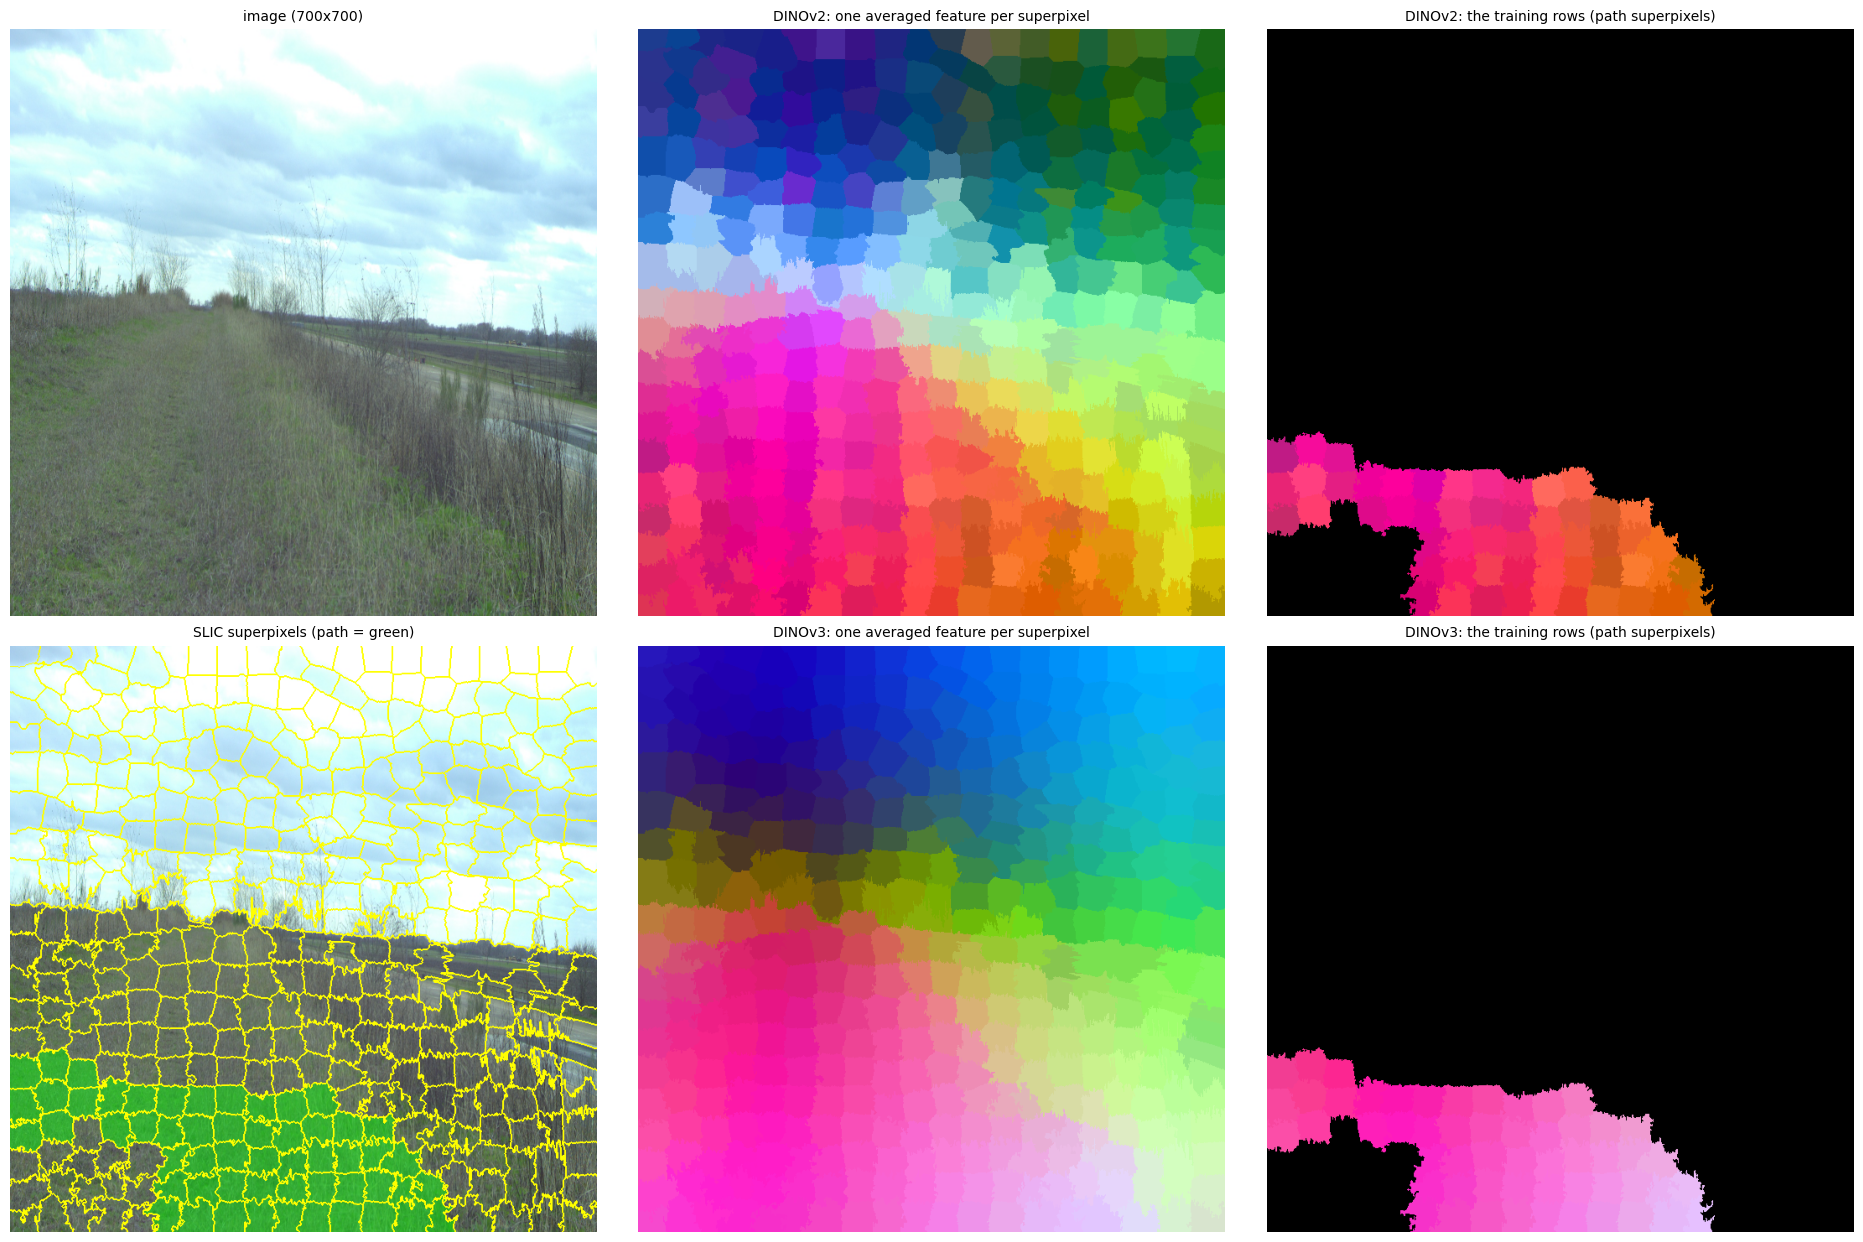

saved -> s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\full_outputs\00002\segment_avg_features_frame002170-1581797367_409.png
DINOv2: 385 superpixels -> 385 averaged vectors, 55 of them are training rows


In [9]:
def segment_average_colors(feature_map, grid):
    """Average the features inside every superpixel -> (ids, one color per id).

    feature_map: (grid, grid, 384) from dense_features()
    Uses the SLIC 'segments' map computed in the section 7 cell.
    """
    seg_small = cv2.resize(segments.astype(np.int32), (grid, grid), interpolation=cv2.INTER_NEAREST)
    ids_kept = []
    averaged_vectors = []
    for sid in np.unique(seg_small):
        cell_mask = seg_small == sid
        if cell_mask.sum() > 0:
            averaged_vectors.append(feature_map[cell_mask].mean(axis=0))   # <- THE averaging step
            ids_kept.append(sid)
    averaged_vectors = np.array(averaged_vectors)

    # one color per averaged vector (3 PCA values, stretched to 0..1)
    compressed = PCA(n_components=3).fit_transform(averaged_vectors)
    low  = np.percentile(compressed, 2, axis=0)
    high = np.percentile(compressed, 98, axis=0)
    colors = np.clip((compressed - low) / (high - low), 0, 1)
    return ids_kept, colors

def paint_segments(ids_kept, colors, only_path=False):
    """Fill every superpixel with its single averaged-feature color (700x700 image)."""
    picture = np.zeros((700, 700, 3))
    for sid, color in zip(ids_kept, colors):
        picture[segments == sid] = color
    if only_path:
        picture[~np.isin(segments, hit_ids)] = 0      # black out non-path superpixels
    return picture

# ---- recompute the dense feature maps (the section 7 cell freed the models) ----
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14', verbose=False).to(device).eval()
fm_v2 = dense_features(dinov2, square700, 700 // 14)
del dinov2
torch.cuda.empty_cache()

from dinov3.hub.backbones import dinov3_vits16
dinov3 = dinov3_vits16(weights=str(DINOV3_WEIGHTS)).to(device).eval()
fm_v3 = dense_features(dinov3, square704, 704 // 16)
del dinov3
torch.cuda.empty_cache()

# ---- average per superpixel and paint ----
ids_v2, colors_v2 = segment_average_colors(fm_v2, 700 // 14)
ids_v3, colors_v3 = segment_average_colors(fm_v3, 704 // 16)

panels = [
    (square700,                                'image (700x700)'),
    (paint_segments(ids_v2, colors_v2),        'DINOv2: one averaged feature per superpixel'),
    (paint_segments(ids_v2, colors_v2, True),  'DINOv2: the training rows (path superpixels)'),
    (slic_pic,                                 'SLIC superpixels (path = green)'),
    (paint_segments(ids_v3, colors_v3),        'DINOv3: one averaged feature per superpixel'),
    (paint_segments(ids_v3, colors_v3, True),  'DINOv3: the training rows (path superpixels)'),
]
fig, axes = plt.subplots(2, 3, figsize=(19, 12.5))
for ax, (picture, title) in zip(axes.ravel(), panels):
    ax.imshow(picture)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / f'segment_avg_features_{images[SHOW_FRAME].stem}.png', dpi=120)
plt.show()
print('saved ->', OUT_DIR / f'segment_avg_features_{images[SHOW_FRAME].stem}.png')
print(f'DINOv2: {len(ids_v2)} superpixels -> {len(ids_v2)} averaged vectors, '
      f'{len(hit_ids)} of them are training rows')